# Validation notebook - Energy two-sample test (2D) for GPU optimisation

This notebook can be used to validates a CUDA/cuBLAS implementation of the **energy two-sample test** in 2D. The code is a bit verbose on the purpose to guide the development of CUDA kernels

**Flow:**
1. Set parameters and **generate one dataset once** (`X`, `Y`) and reuse it everywhere in the pipeline, data generator is quite complicated to produce diffent data set scenarios (shifts and correlations)
2. Define reference functions
3. Build pooled distance matrix `D` (CPU; keep `N` modest for this step)
4. Compute:
   - Energy statistic `E` (direct, biased)
   - Quadratic score `S = wᵀ D w` (GPU-friendly)
   - With the conventions used here, `E = -S`
5. Compute permutation p-value (with the correct tail)

You can also load scores dumped by your CUDA code and compute p-values here


In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility - set the same seed
rng = np.random.default_rng(7)


## 1) Choose a test case and generate data

Change only this cell to switch datasets.

Recommended CPU-validation sizes:
- max sample sizes ~ `2000 - 3000` for quick runs
- avoid `N > ~5000` on CPU unless you have time/RAM


In [110]:
""" configure the generator first """
case = "covdiff"   # one of: "null", "mean_shift", "covdiff", "mixture"
n = 600
m = 600
seed = 42

# Permutations for CPU validation (increase slowly)
B = 4000

def gen_case(case: str, n: int, m: int, seed: int = 7):
    rng = np.random.default_rng(seed)

    if case == "null":
        X = rng.normal(size=(n,2))
        Y = rng.normal(size=(m,2))
        return X, Y

    if case == "mean_shift":
        X = rng.normal(size=(n,2))
        mu = np.array([0.35, -0.25])
        Y = rng.normal(size=(m,2)) + mu
        return X, Y

    if case == "covdiff":
        X = rng.normal(size=(n,2))
        mu = np.array([0.15, 0.05])
        Sigma = np.array([[1.0, 0.55],
                          [0.55, 1.25]])
        L = np.linalg.cholesky(Sigma)
        Y = rng.normal(size=(m,2)) @ L.T + mu
        return X, Y

    if case == "mixture":
        X = rng.normal(size=(n,2))
        mix = rng.uniform(size=m) < 0.5
        Y = np.empty((m,2))
        Y[mix]  = rng.normal(loc=[0.6, 0.0], scale=1.0, size=(mix.sum(),2))
        Y[~mix] = rng.normal(loc=[-0.6, 0.0], scale=1.0, size=((~mix).sum(),2))
        return X, Y

    raise ValueError(f"Unknown case: {case}")

X, Y = gen_case(case, n, m, seed=seed)
Z = np.vstack([X, Y])
N = n + m

print(f"Case={case!r}, n={n}, m={m}, N={N}, seed={seed}, B={B}")


Case='covdiff', n=600, m=600, N=1200, seed=42, B=4000


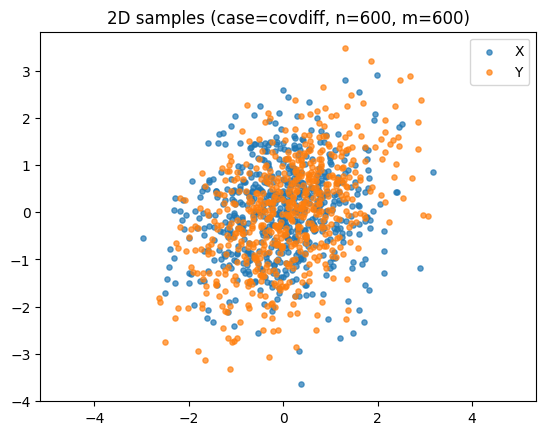

In [111]:
""" Check the data! """
plt.figure()
plt.scatter(X[:,0], X[:,1], s=14, alpha=0.7, label="X")
plt.scatter(Y[:,0], Y[:,1], s=14, alpha=0.7, label="Y")
plt.axis("equal")
plt.title(f"2D samples (case={case}, n={n}, m={m})")
plt.legend()
plt.show()


## 2) Reference functions

We compute:

### 2.1 Pooled distance matrix
`D[i,j] = ||Z[i]-Z[j]||` (Euclidean) -> can chose different as well, but stick to that one.

### 2.2 Energy statistic (direct, biased)
$E = 2\,\overline{\|X-Y\|} - \overline{\|X-X\|} - \overline{\|Y-Y\|}$

### 2.3 Quadratic score (GPU-friendly)
Weights:
- `w_i = +1/n` for X points
- `w_i = -1/m` for Y points

Score:
$S = w^T D w$

With the conventions above (and including diagonals consistently),
$E = -S.$


In [112]:
""" compute functions """
def pairwise_distances(Z: np.ndarray) -> np.ndarray:
    diff = Z[:, None, :] - Z[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))

def energy_direct(D: np.ndarray, n: int, m: int) -> float:
    idx_x = np.arange(n)
    idx_y = np.arange(n, n+m)
    cross = D[np.ix_(idx_x, idx_y)].mean()
    within_x = D[np.ix_(idx_x, idx_x)].mean()
    within_y = D[np.ix_(idx_y, idx_y)].mean()
    return 2.0 * cross - within_x - within_y

def weights_vector(n: int, m: int) -> np.ndarray:
    w = np.empty(n+m, dtype=np.float64)
    w[:n] = 1.0 / n
    w[n:] = -1.0 / m;
    return w

def score_quadratic(D: np.ndarray, w: np.ndarray) -> float:
    return float(w @ (D @ w))


## 3) Build pooled distance matrix `D` (CPU)

This is **O(N²)** in both time and memory.
Keep `N` modest for CPU validation (e.g. ≤ 5000).


In [113]:
D = pairwise_distances(Z)
print("D shape:", D.shape, " dtype:", D.dtype)


D shape: (1200, 1200)  dtype: float64


## 4) Compute observed statistics: `E` and `S`

We print both and verify the sign relation `E ≈ -S` (up to tiny numeric differences).


In [114]:
w_obs = weights_vector(n, m)

E_obs = energy_direct(D, n, m)
S_obs = score_quadratic(D, w_obs)

print(f"E_obs (direct energy)   = {E_obs:.6f}")
print(f"S_obs (quadratic score) = {S_obs:.6f}")
print(f"-S_obs                  = {-S_obs:.6f}")
print(f"Check E_obs + S_obs      = {E_obs + S_obs:.3e}  (should be ~0)")


E_obs (direct energy)   = 0.017106
S_obs (quadratic score) = -0.017106
-S_obs                  = 0.017106
Check E_obs + S_obs      = -6.939e-18  (should be ~0)


## 5) Permutation test p-value (correct tail)

Because `E = -S` and “more different” means **larger E**, it means “more different” means **smaller S**.

So for the quadratic score `S`, the extreme tail is the **left tail**:
$p = \frac{1 + \#\{S_{perm} \le S_{obs}\}}{B+1}.$

(Equivalently, you can test `T=-S` using the right tail.)


S_obs = -0.017106
p-value (left tail for S) ~= 0.013747  (B=4000)


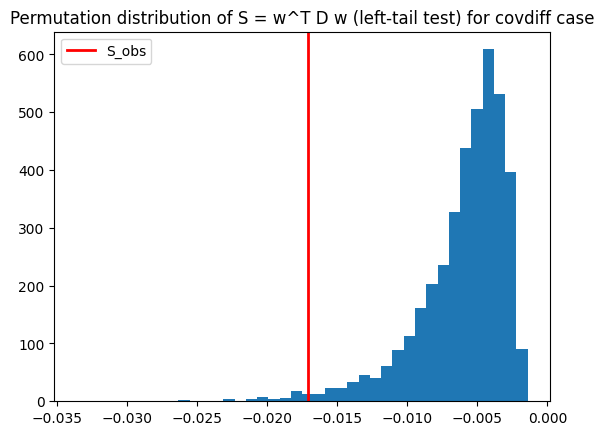

In [115]:
""" second part of the heavy lifting - permuations """
def perm_test_quadratic_lefttail(D: np.ndarray, n: int, m: int, B: int = 2000, seed: int = 123):
    rng = np.random.default_rng(seed)
    N = n + m

    w_obs = weights_vector(n, m)
    S_obs = score_quadratic(D, w_obs)

    base = np.zeros(N, dtype=np.int8)
    base[:n] = 1  # 1 means X, 0 means Y

    S_perm = np.empty(B, dtype=np.float64)
    for b in range(B):
        perm = rng.permutation(base)
        w = np.where(perm == 1, 1.0/n, -1.0/m).astype(np.float64)
        S_perm[b] = score_quadratic(D, w)

    p = (1.0 + np.sum(S_perm <= S_obs)) / (B + 1.0)  # LEFT TAIL (important)
    return S_obs, S_perm, p

S_obs2, S_perm, p = perm_test_quadratic_lefttail(D, n, m, B=B, seed=2026)

print(f"S_obs = {S_obs2:.6f}")
print(f"p-value (left tail for S) ~= {p:.6f}  (B={B})")

plt.figure()
plt.hist(S_perm, bins=40)
plt.axvline(S_obs2, linewidth=2, label="S_obs", color="red")
plt.title(f"Permutation distribution of S = w^T D w (left-tail test) for {case} case")
plt.legend()
plt.show()
